# Aprendizaje automatico - clase 8
## Alumno: Enzo Ariel Melián

## 1. Preparación del dataset

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

clientes_df = pd.read_csv('dataset_segmentacion_clientes.csv')
clientes_df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


## 2. Exploracion inicial del dataset




In [14]:
clientes_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


In [15]:
clientes_df.describe()


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,0.023814,-0.010523
std,4.471079,154.904372,12.914111,0.431467,0.356623,1.009325,1.679810
min,0.100000,86.994100,3.163206,0.000000,0.000000,-3.566175,-2.993585
25%,2.278418,90.766945,6.603950,0.000000,0.000000,-0.654168,-1.424864
50%,4.134580,180.223799,9.974407,0.296475,0.165559,0.076845,0.013148
75%,11.214919,449.719033,34.341360,1.000000,0.800000,0.728304,1.407124
max,14.603388,452.973583,38.348156,1.000000,0.800000,2.863317,2.995020


## 3. Transformacion de datos (para escalar variables antes del aplicar el logaritmo)

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(clientes_df)
X_scaled

array([[ 1.18104766, -0.43201153,  1.3002238 , ...,  1.29867122,
        -1.81477864, -1.49312953],
       [ 1.38269638, -0.4492187 ,  1.44497872, ..., -0.9461957 ,
         0.61601448,  1.26651426],
       [-0.82202607,  1.30503906, -0.75584112, ..., -0.9461957 ,
        -0.07061305, -0.42514329],
       ...,
       [-0.45202644,  1.29540873, -0.73756682, ...,  1.29867122,
        -0.54134456,  0.22843616],
       [ 1.27632981, -0.44336324,  1.45048539, ..., -0.50162332,
         0.03516985,  1.74320469],
       [ 1.34838143, -0.43390428,  1.4601441 , ...,  0.20277751,
         0.13267136,  1.5419999 ]])

## 4. Método del codo

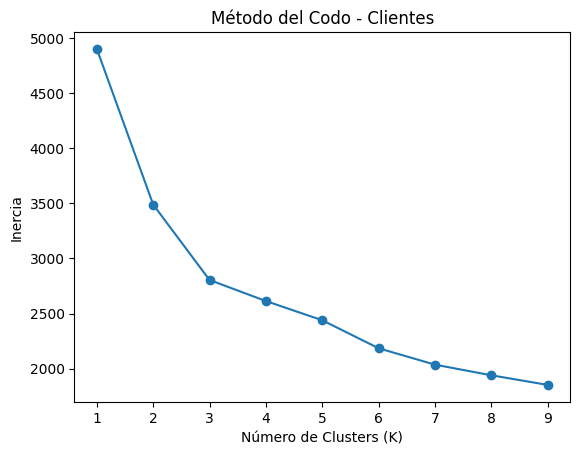

In [21]:
inercia = []
valores_k = range(1, 10)
for k in valores_k:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inercia.append(kmeans.inertia_)

plt.plot(valores_k, inercia, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo - Clientes")
plt.show()

## 5. Coeficiente de Silueta (Silhouette Score)

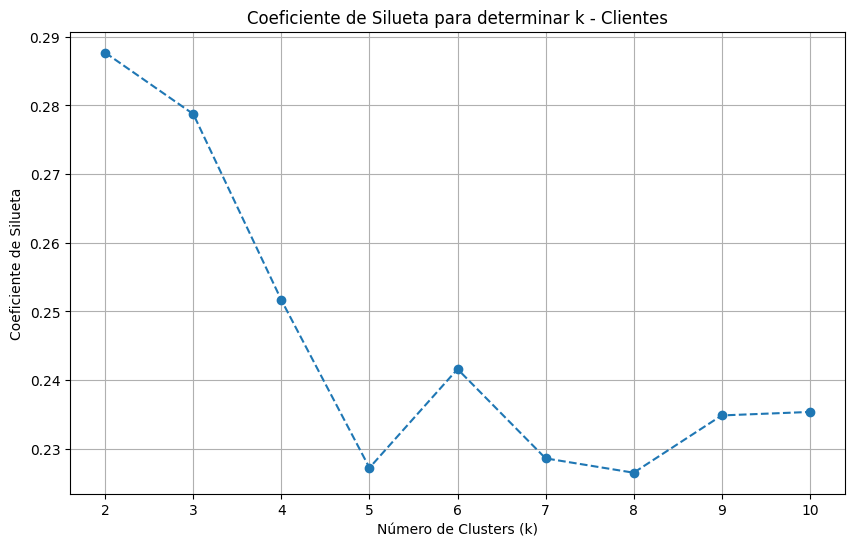

In [22]:
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Graficar el coeficiente de silueta
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Coeficiente de Silueta para determinar k - Clientes')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silueta')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### Aplicación de K-Means y Asignación de Clusters

In [25]:
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
clientes_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Mostrar las primeras filas con la nueva columna de Cluster
clientes_df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform,Cluster
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905,0
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460,0
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173,1
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026,2
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522,1


### Análisis de Centroides por Cluster

In [26]:
cluster_summary = clientes_df.groupby('Cluster').mean()
print(cluster_summary)

         purchase_freq_month  avg_basket_usd  time_on_site_min  \
Cluster                                                          
0                  11.961153      179.999315         35.022131   
1                   1.917276      450.192095          5.868234   
2                   4.091883       89.957567         10.003793   
3                   1.774252      450.053173          6.082675   

         discount_sensitivity  returns_rate  noise_gauss  noise_uniform  
Cluster                                                                  
0                    0.541539      0.332461     0.046581      -0.039583  
1                    0.365219      0.036974    -0.059525       0.094284  
2                    0.379465      0.298761    -0.032045      -0.132205  
3                    0.350725      0.724773     0.167203       0.153242  


Recalculados los centroides para 4 clusters, podemos describir los nuevos perfiles de clientes:

### **Cluster 0 (Alta Frecuencia y Estancia,  Ticket Medio):**

- purchase_freq_month: Muy alta (aproximadamente 12 compras al mes)
- avg_basket_usd: Medio (aproximadamente $180)
- time_on_site_min: Alto (aproximadamente 35 minutos)
- discount_sensitivity: Media (0.54)
- returns_rate: Media (0.33)

- Perfil: Similar al Cluster 0 del modelo de 3 clusters. Clientes muy activos y leales, con compras frecuentes y una permanencia alta en el sitio. Son moderadamente sensibles a los descuentos.

### **Cluster 1 (Frecuencia Muy Baja, Ticket Muy Alto, Bajas Devoluciones):**

- purchase_freq_month: Muy baja (aproximadamente 1.9 compras al mes)
- avg_basket_usd: Muy alto (aproximadamente $450)
time_on_site_min: Muy bajo (aproximadamente 5.8 minutos)
- discount_sensitivity: Baja a media (0.36)
- returns_rate: Muy baja (0.03)

- Perfil: Estos clientes realizan compras muy costosas pero muy esporádicamente y pasan muy poco tiempo en el sitio. Lo más notable es su tasa de devoluciones extremadamente baja. Esto sugiere que, aunque compran poco, cuando lo hacen, están muy satisfechos con su elección y rara vez devuelven productos. Podrían ser compradores de artículos de lujo o muy específicos.

### **Cluster 2 (Frecuencia y Estancia Bajas, Ticket Bajo):**

- purchase_freq_month: Baja (aproximadamente 4 compras al mes)
- avg_basket_usd: Bajo (aproximadamente $90)
- time_on_site_min: Bajo (aproximadamente 10 minutos)
- discount_sensitivity: Baja a media (0.38)
- returns_rate: Media (0.29)

- Perfil: Similar al Cluster 1 del modelo de 3 clusters. Clientes menos activos, con baja frecuencia de compra y tickets pequeños. Podrían ser clientes esporádicos o de bajo valor, con una tasa de devolución promedio.

### **Cluster 3 (Frecuencia Muy Baja, Ticket Muy Alto, Altas Devoluciones):**

- purchase_freq_month: Muy baja (aproximadamente 1.77 compras al mes)
- avg_basket_usd: Muy alto (aproximadamente $450)
- time_on_site_min: Muy bajo (aproximadamente 6.08 minutos)
- discount_sensitivity: Baja a media (0.35)
- returns_rate: Muy alta (0.72)

- Perfil: Este cluster se ha segregado del anterior 'Cluster 2' del modelo de 3 clusters. Al igual que el Cluster 1 de este modelo, estos clientes también realizan compras de ticket muy alto con muy baja frecuencia y poca permanencia. Sin embargo, se distinguen por tener una tasa de devoluciones muy alta. Esto podría indicar que son compradores impulsivos de alto valor o que tienen expectativas muy altas que no siempre se cumplen. Podrían ser clientes 'problemáticos' a pesar de su alto ticket.

Con 4 clusters, hemos logrado diferenciar entre los clientes de "ticket muy alto y baja frecuencia" en dos subgrupos basados en su tasa de devoluciones, lo que ofrece una visión más matizada de estos segmentos.

